In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle
import os
from scipy.signal import find_peaks
from numba import njit
from scipy.optimize import curve_fit

In [ ]:
carpeta = 'Be_GSEP'
def phase_fold (hjd, period):
    return ((hjd - hjd[0]) % period) / period
def lombscargle (hjd, mags, f_min, f_max, n_freq):
    frequency, power = LombScargle(hjd, mags).autopower(minimum_frequency=f_min, maximum_frequency=f_max, samples_per_peak=n_freq)
    return frequency, power
def modelo_senoidal(t, A, f, fase, C):
    """Modelo armónico para la curva de luz."""
    return A * np.sin(2 * np.pi * f * t + fase) + C

def pre_blanqueo_iterativo(hjd, mags, j, max_iter=3):
    residuales = mags.copy()
    frecuencias_extraidas = []
    t_norm = hjd - hjd[0]
    
    plt.figure(figsize=(15, 4 * max_iter))
    
    for i in range(max_iter):
        #frecuencia, power = lombscargle(hjd, residuales, f_min=6, f_max=15, n_freq=20)
        #f_pico = frecuencia[np.argmax(power)]
        frecuencia, power = lombscargle(hjd, residuales, f_min=0.5, f_max=5.0, n_freq=20)
        f_pico = frecuencia[np.argmax(power)]
    
        if np.max(power) < 0.00005: 
            print(f"Iteración {i+1}: Potencia máxima ({np.max(power):.5f}) por debajo del umbral. Deteniendo.")
            break
        #if np.max(power) < 0.05:
            #print(f"Iteración {i+1}: Potencia máxima ({np.max(power):.3f}) por debajo del umbral. Deteniendo.")
            #break
            
        p0 = [np.std(residuales), f_pico, 0.0, np.mean(residuales)]
        
        bounds = (
            [0, f_pico - 0.05, -np.inf, -np.inf], 
            [np.inf, f_pico + 0.05, np.inf, np.inf]
        )
        
        try:
            popt, _ = curve_fit(modelo_senoidal, t_norm, residuales, p0=p0, bounds=bounds, maxfev=10000)
        except RuntimeError:
            print(f"El ajuste analítico no convergió en la iteración {i+1}")
            break
            
        A_opt, f_opt, fase_opt, C_opt = popt
        frecuencias_extraidas.append(f_opt)
        senal_ajustada = modelo_senoidal(t_norm, A_opt, f_opt, fase_opt, C_opt)
        
        residuales = residuales - senal_ajustada
        
        plt.subplot(max_iter, 1, i + 1)
        plt.plot(frecuencia, power, color='black')
        plt.axvline(f_pico, color='red', linestyle='--', label=f'Frecuencia extraída: {f_pico:.4f} d⁻¹')
        plt.title(f'Iteración {i+1}: Espectro Lomb-Scargle antes del blanqueo')
        plt.ylabel('Potencia')
        if i == max_iter - 1: plt.xlabel('Frecuencia (d⁻¹)')
        plt.legend()
    plt.savefig(f'{j}-Espectro_LombScargle.png', dpi=300)
    plt.tight_layout()
    plt.show()
    
    return frecuencias_extraidas, residuales

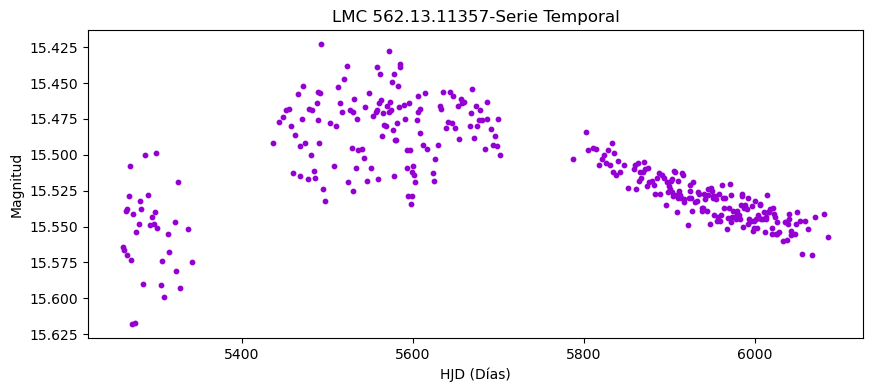

In [25]:
#Estrella #1 - LMC 562.13.11357
estrella_1 = os.path.join(carpeta, 'LMC562.13.11357.dat')
df_1 = pd.read_csv(estrella_1, sep = r"\s+", header = None)
df_1.columns = ['HJD', 'Magnitude', 'Error']
hjd_1 = df_1['HJD'].values
magnitude_1 = df_1['Magnitude'].values
error_1 = df_1['Error'].values
plt.figure(figsize=(10, 4))
plt.scatter(hjd_1, magnitude_1, s=10, color='darkviolet')
plt.gca().invert_yaxis()
plt.title('LMC 562.13.11357-Serie Temporal')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.savefig('1-Serie_Temporal.png', dpi=300)
plt.show()

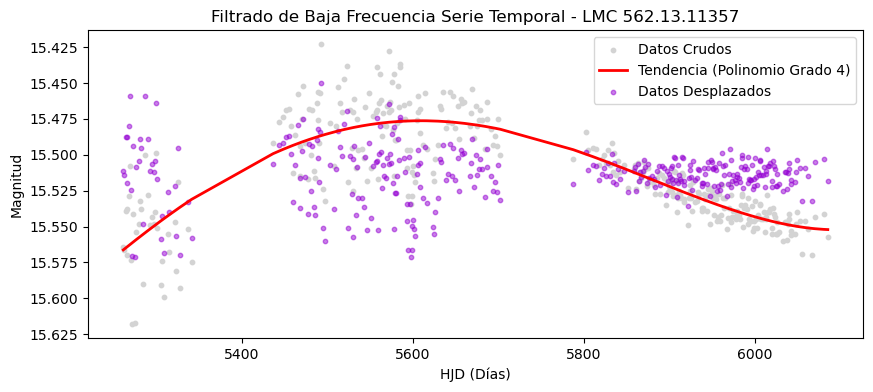


--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---


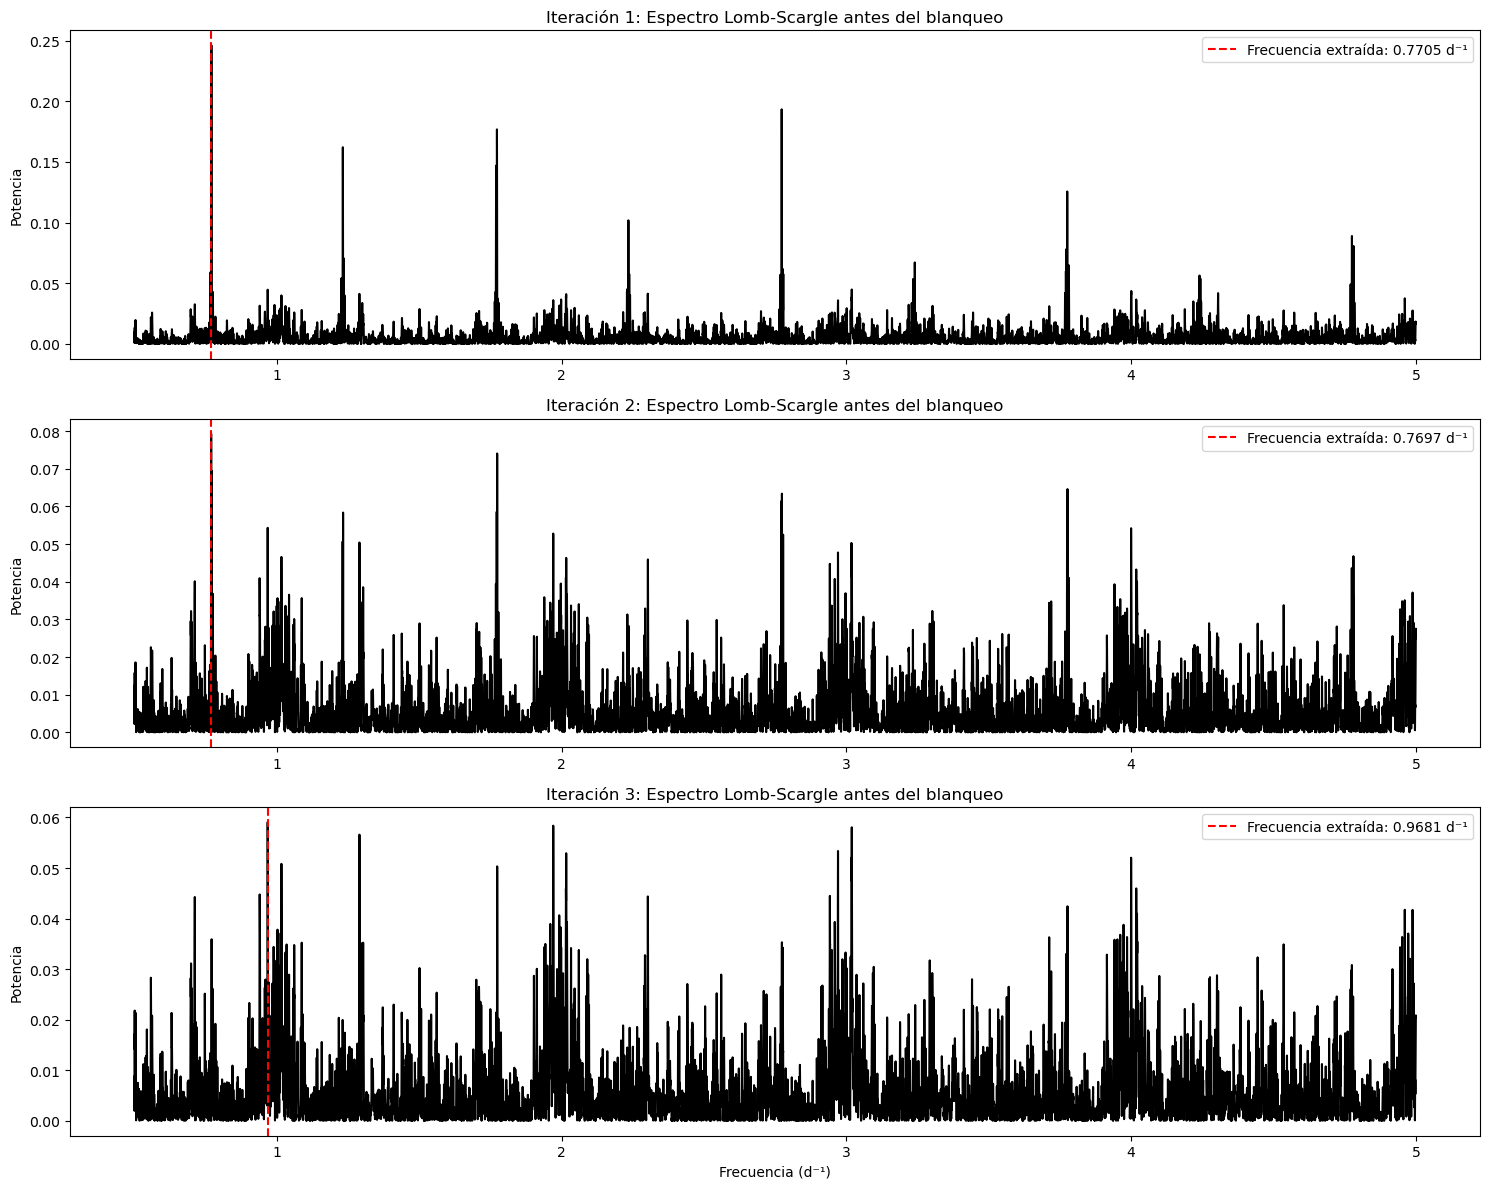


Frecuencias de modos no radiales detectadas:
Modo 1: f = 0.7705 d⁻¹ (Periodo = 1.2979 días)
Modo 2: f = 0.7697 d⁻¹ (Periodo = 1.2993 días)
Modo 3: f = 0.9682 d⁻¹ (Periodo = 1.0329 días)


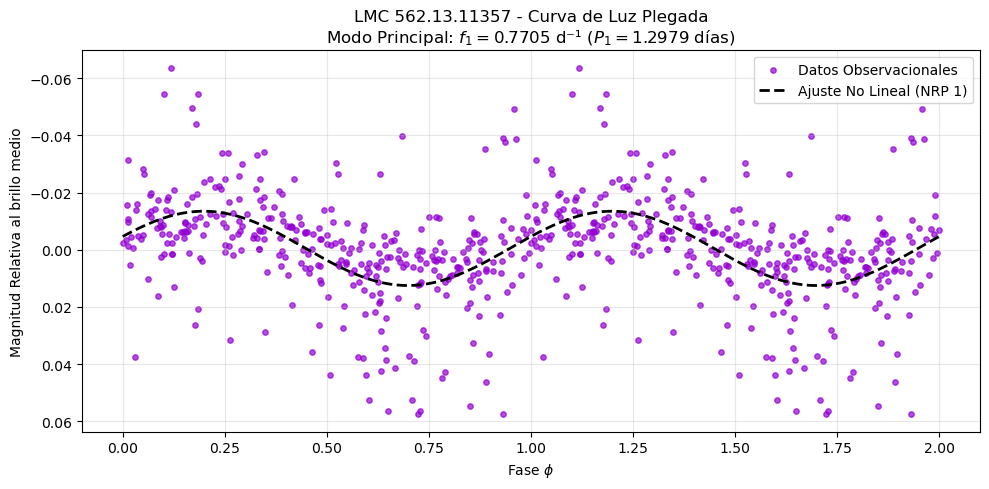

In [ ]:
# =========================================================
# 1. DETRENDING: Modelado analítico de la variación del disco
# =========================================================
grado_polinomio = 4 
coeficientes = np.polyfit(hjd_1, magnitude_1, grado_polinomio)
tendencia_disco = np.polyval(coeficientes, hjd_1)

magnitud_detrended = magnitude_1 - tendencia_disco

plt.figure(figsize=(10, 4))
plt.scatter(hjd_1, magnitude_1, s=10, color='lightgray', label='Datos Crudos')
plt.plot(hjd_1, tendencia_disco, color='red', linewidth=2, label=f'Tendencia (Polinomio Grado {grado_polinomio})')
plt.scatter(hjd_1, magnitud_detrended + np.mean(magnitude_1), s=10, color='darkviolet', alpha=0.5, label='Datos Desplazados')
plt.gca().invert_yaxis()
plt.title('Filtrado de Baja Frecuencia Serie Temporal - LMC 562.13.11357')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.legend()
plt.savefig('1-Detrending.png', dpi=300)
plt.show()

# =========================================================
# 2. EJECUCIÓN DEL PRE-BLANQUEO ESTABILIZADO
# =========================================================
print("\n--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---")

frecuencias_nrp, ruido_final = pre_blanqueo_iterativo(hjd_1, magnitud_detrended,j=1, max_iter=3)

print("\nFrecuencias de modos no radiales detectadas:")
for idx, freq in enumerate(frecuencias_nrp):
    print(f"Modo {idx+1}: f = {freq:.4f} d⁻¹ (Periodo = {1/freq:.4f} días)")
# =========================================================
# 3. CURVA DE LUZ PLEGADA (PHASE-FOLDING) DEL MODO PRINCIPAL
# =========================================================


f1 = frecuencias_nrp[0] 
periodo_1 = 1 / f1
fase_1 = phase_fold(hjd_1, periodo_1)

plt.figure(figsize=(10, 5))


plt.scatter(fase_1, magnitud_detrended, s=15, color='darkviolet', alpha=0.7, label='Datos Observacionales')
plt.scatter(fase_1 + 1, magnitud_detrended, s=15, color='darkviolet', alpha=0.7)

def modelo_fase(fase, A, fase_offset, C):
    return A * np.sin(2 * np.pi * fase + fase_offset) + C

p0 = [0.02, 0.0, 0.0] 
popt, _ = curve_fit(modelo_fase, fase_1, magnitud_detrended, p0=p0)
A_ajuste, fase_offset_ajuste, C_ajuste = popt

fase_sintetica = np.linspace(0, 2, 200)
modelo_armonico_ajustado = modelo_fase(fase_sintetica, A_ajuste, fase_offset_ajuste, C_ajuste)

plt.plot(fase_sintetica, modelo_armonico_ajustado, color='black', linewidth=2, linestyle='--', label='Ajuste No Lineal (NRP 1)')


plt.gca().invert_yaxis() 

plt.title(f'LMC 562.13.11357 - Curva de Luz Plegada\nModo Principal: $f_1 = {f1:.4f}$ d⁻¹ ($P_1 = {periodo_1:.4f}$ días)')
plt.xlabel('Fase $\phi$')
plt.ylabel('Magnitud Relativa al brillo medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('1-Curva_Luz_Plegada.png', dpi=300)
plt.show()

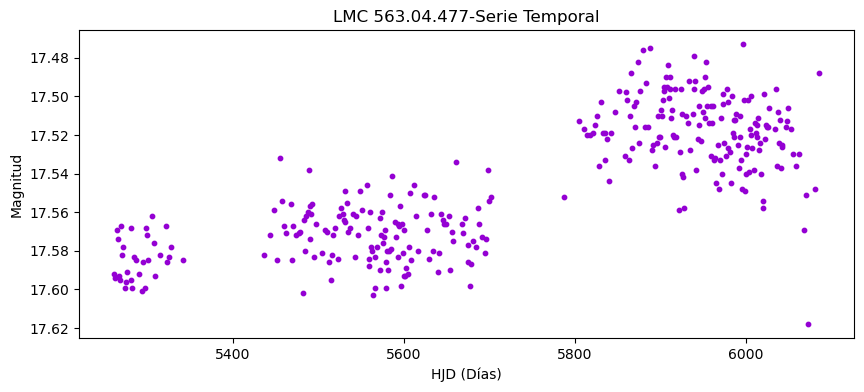

In [34]:
#Estrella #2 - LMC 563.04.477
estrella_2 = os.path.join(carpeta, 'LMC563.04.477.dat')
df_2 = pd.read_csv(estrella_2, sep = r"\s+", header = None)
df_2.columns = ['HJD', 'Magnitude', 'Error']
hjd_2 = df_2['HJD'].values
magnitude_2 = df_2['Magnitude'].values
error_2 = df_2['Error'].values
plt.figure(figsize=(10, 4))
plt.scatter(hjd_2, magnitude_2, s=10, color='darkviolet')
plt.gca().invert_yaxis()
plt.title('LMC 563.04.477-Serie Temporal')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.savefig('2-Serie_Temporal.png', dpi=300)
plt.show()


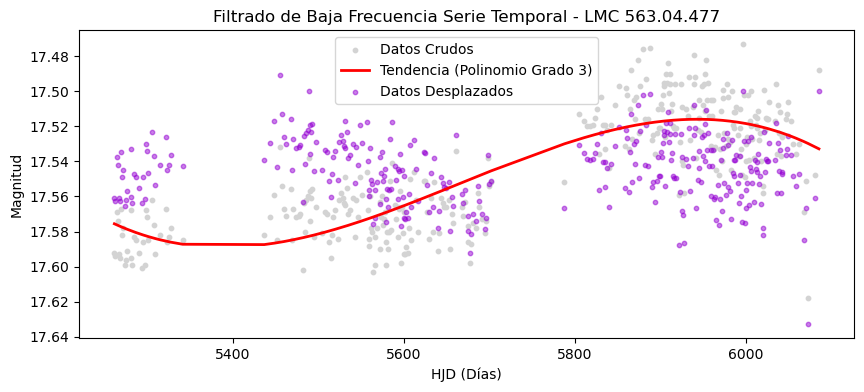


--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---


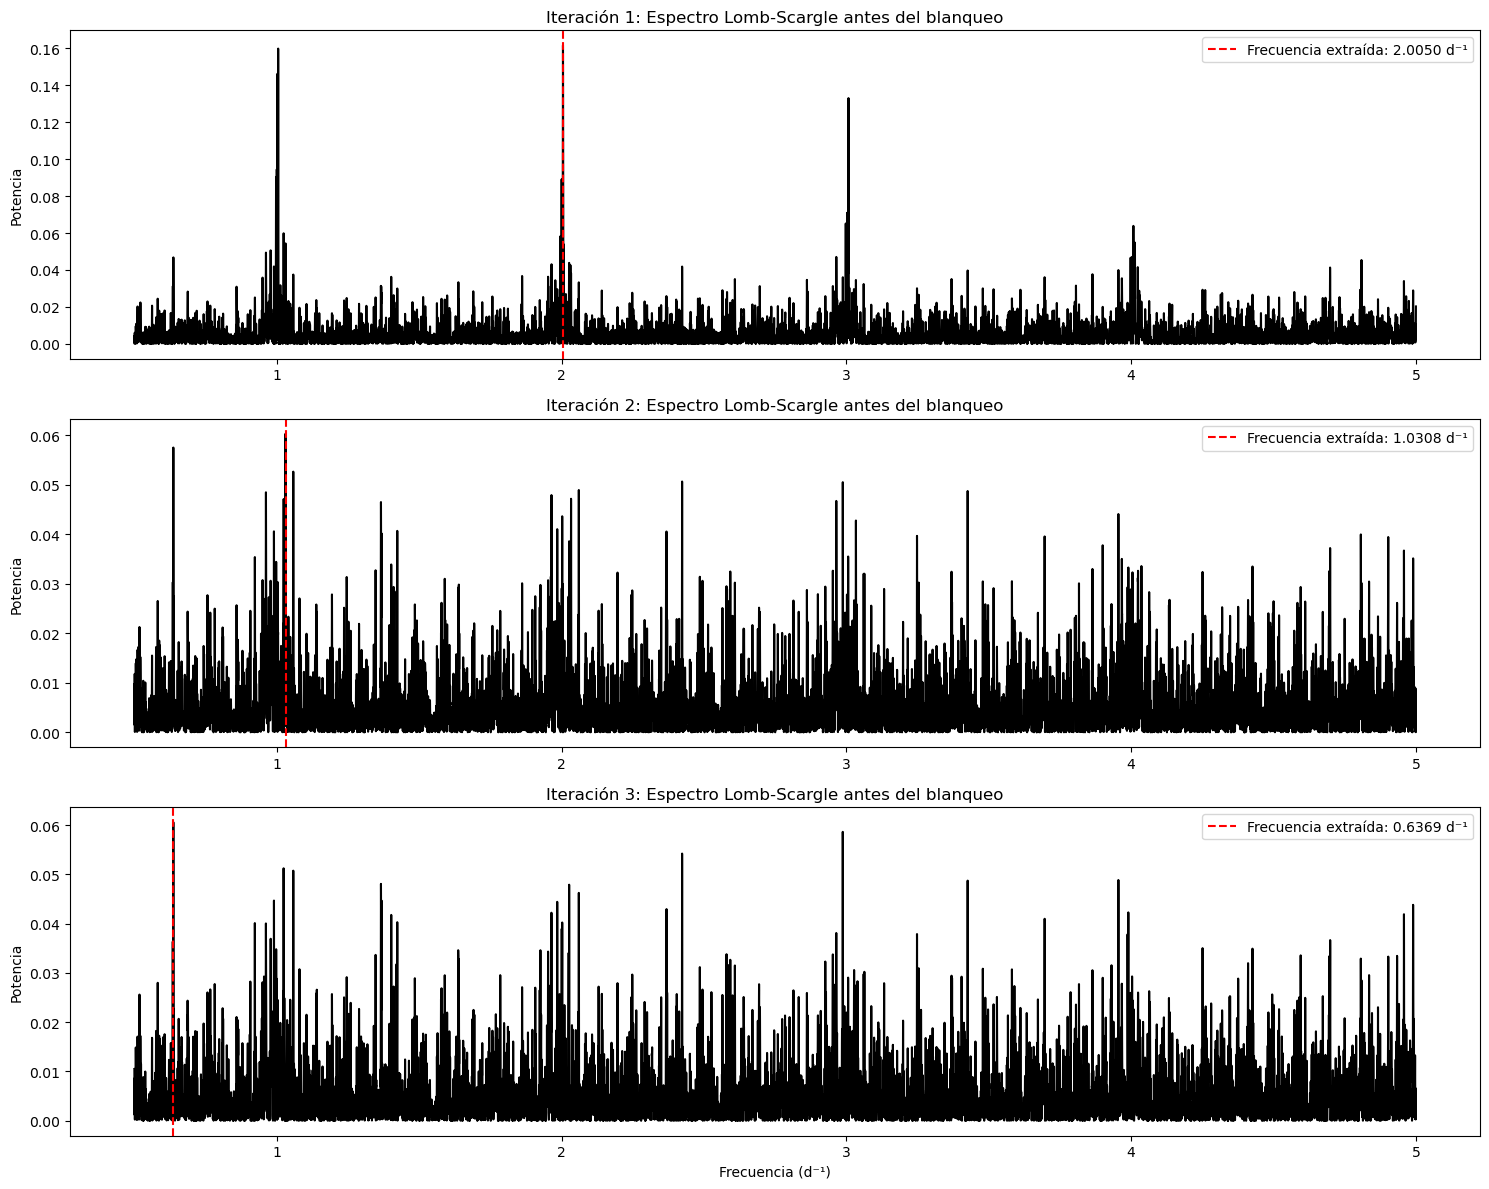


Frecuencias de modos no radiales detectadas:
Modo 1: f = 2.0050 d⁻¹ (Periodo = 0.4988 días)
Modo 2: f = 1.0308 d⁻¹ (Periodo = 0.9701 días)
Modo 3: f = 0.6369 d⁻¹ (Periodo = 1.5702 días)


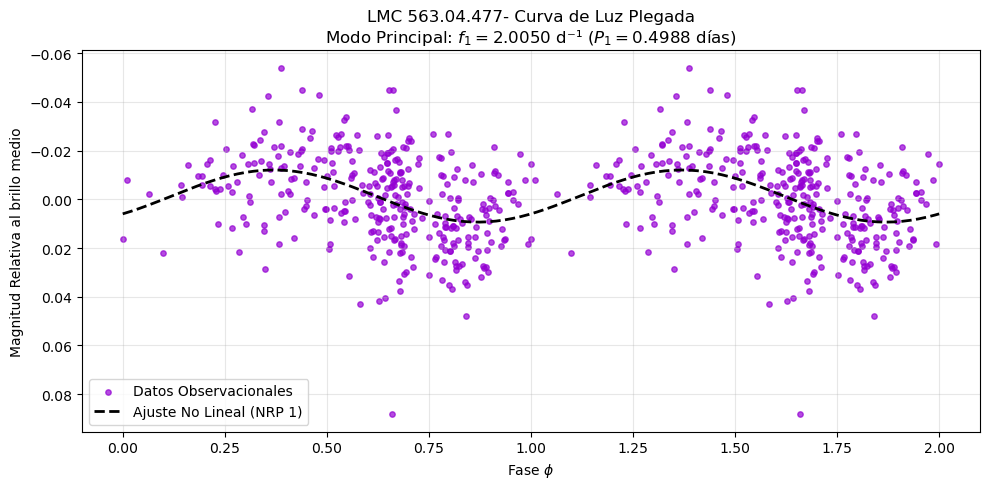

In [ ]:
# =========================================================
# 1. DETRENDING: Modelado analítico de la variación del disco
# =========================================================
grado_polinomio = 3  
coeficientes = np.polyfit(hjd_2, magnitude_2, grado_polinomio)
tendencia_disco = np.polyval(coeficientes, hjd_2)

magnitud_detrended = magnitude_2 - tendencia_disco

plt.figure(figsize=(10, 4))
plt.scatter(hjd_2, magnitude_2, s=10, color='lightgray', label='Datos Crudos')
plt.plot(hjd_2, tendencia_disco, color='red', linewidth=2, label=f'Tendencia (Polinomio Grado {grado_polinomio})')
plt.scatter(hjd_2, magnitud_detrended + np.mean(magnitude_2), s=10, color='darkviolet', alpha=0.5, label='Datos Desplazados')
plt.gca().invert_yaxis()
plt.title('Filtrado de Baja Frecuencia Serie Temporal - LMC 563.04.477')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.legend()
plt.savefig('2-Detrending.png', dpi=300)
plt.show()

# =========================================================
# 2. EJECUCIÓN DEL PRE-BLANQUEO ESTABILIZADO
# =========================================================
print("\n--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---")

frecuencias_nrp, ruido_final = pre_blanqueo_iterativo(hjd_2, magnitud_detrended, j=2, max_iter=3)

print("\nFrecuencias de modos no radiales detectadas:")
for idx, freq in enumerate(frecuencias_nrp):
    print(f"Modo {idx+1}: f = {freq:.4f} d⁻¹ (Periodo = {1/freq:.4f} días)")
# =========================================================
# 3. CURVA DE LUZ PLEGADA (PHASE-FOLDING) DEL MODO PRINCIPAL
# =========================================================


f2 = frecuencias_nrp[0] 
periodo_2 = 1 / f2
fase_2 = phase_fold(hjd_2, periodo_2)


plt.figure(figsize=(10, 5))


plt.scatter(fase_2, magnitud_detrended, s=15, color='darkviolet', alpha=0.7, label='Datos Observacionales')
plt.scatter(fase_2 + 1, magnitud_detrended, s=15, color='darkviolet', alpha=0.7)

def modelo_fase(fase, A, fase_offset, C):
    return A * np.sin(2 * np.pi * fase + fase_offset) + C

p0 = [0.02, 0.0, 0.0] 
popt, _ = curve_fit(modelo_fase, fase_2, magnitud_detrended, p0=p0)
A_ajuste, fase_offset_ajuste, C_ajuste = popt

fase_sintetica = np.linspace(0, 2, 200)
modelo_armonico_ajustado = modelo_fase(fase_sintetica, A_ajuste, fase_offset_ajuste, C_ajuste)


plt.plot(fase_sintetica, modelo_armonico_ajustado, color='black', linewidth=2, linestyle='--', label='Ajuste No Lineal (NRP 1)')

plt.gca().invert_yaxis() 

plt.title(f'LMC 563.04.477- Curva de Luz Plegada\nModo Principal: $f_1 = {f2:.4f}$ d⁻¹ ($P_1 = {periodo_2:.4f}$ días)')
plt.xlabel('Fase $\phi$')
plt.ylabel('Magnitud Relativa al brillo medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('2-Curva_Luz_Plegada.png', dpi=300)
plt.show()

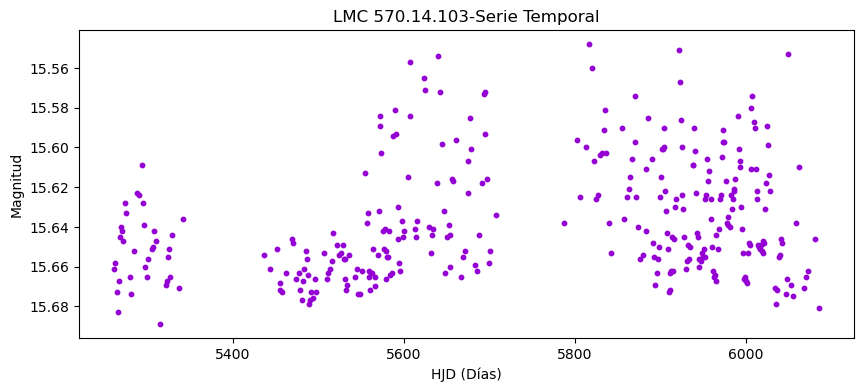

In [36]:
#Estrella #3 - LMC 570.14.103
estrella_3 = os.path.join(carpeta, 'LMC570.14.103.dat')
df_3 = pd.read_csv(estrella_3, sep = r"\s+", header = None)
df_3.columns = ['HJD', 'Magnitude', 'Error']
hjd_3 = df_3['HJD'].values
magnitude_3 = df_3['Magnitude'].values
error_3 = df_3['Error'].values
plt.figure(figsize=(10, 4))
plt.scatter(hjd_3, magnitude_3, s=10, color='darkviolet')
plt.gca().invert_yaxis()
plt.title('LMC 570.14.103-Serie Temporal')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.savefig('3-Serie_Temporal.png', dpi=300)

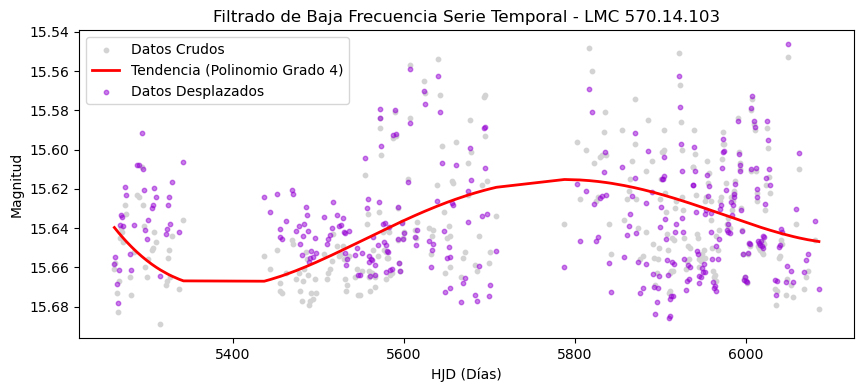


--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---


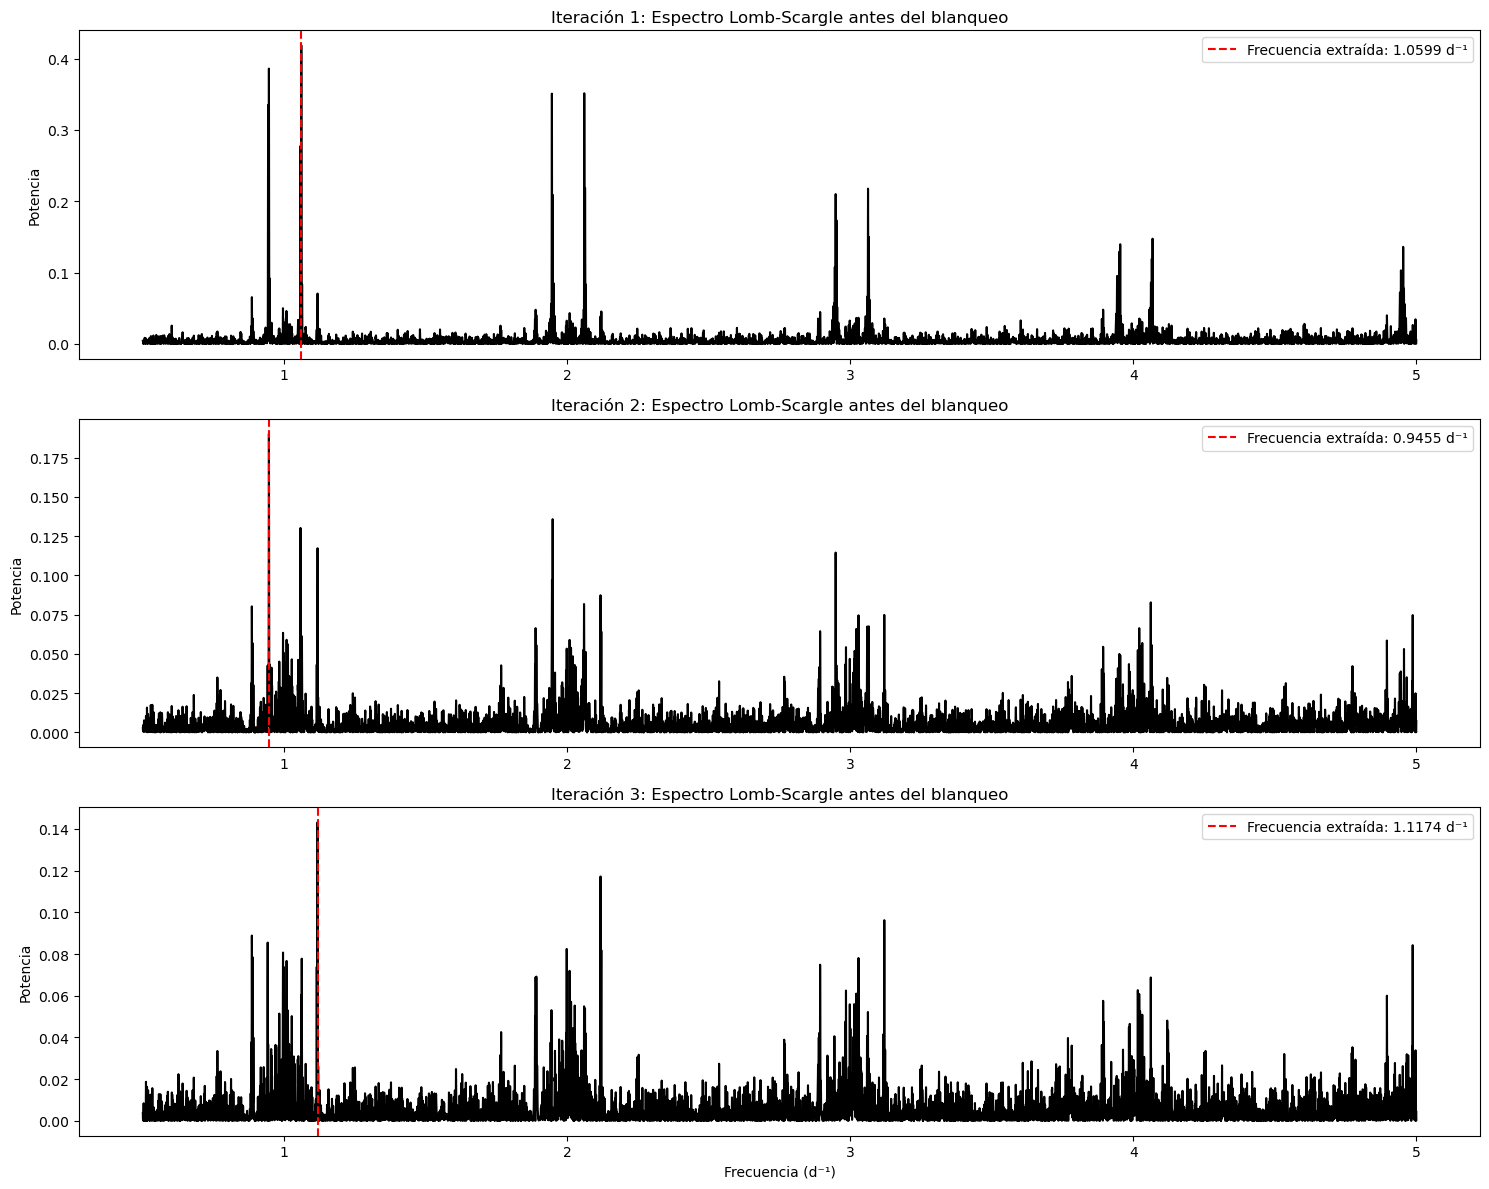


Frecuencias de modos no radiales detectadas:
Modo 1: f = 1.0599 d⁻¹ (Periodo = 0.9435 días)
Modo 2: f = 0.9455 d⁻¹ (Periodo = 1.0576 días)
Modo 3: f = 1.1174 d⁻¹ (Periodo = 0.8949 días)


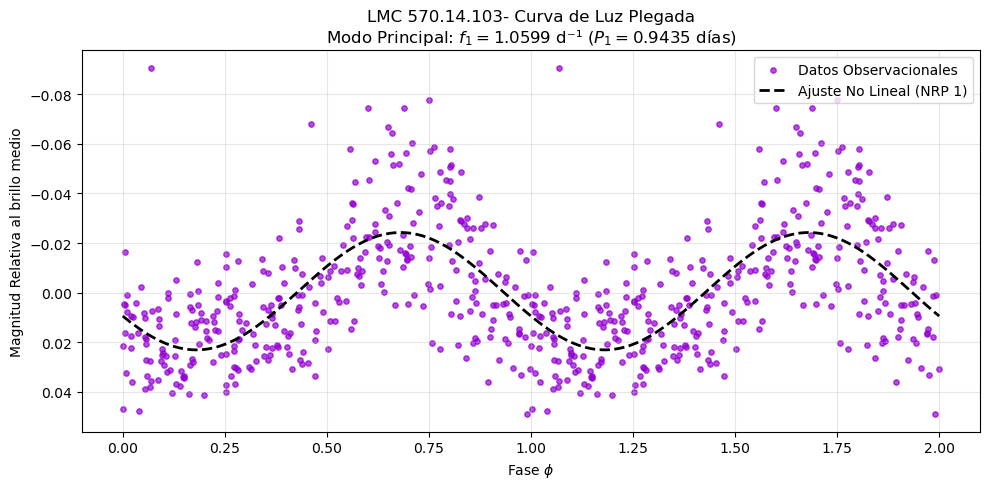

In [ ]:
# =========================================================
# 1. DETRENDING: Modelado analítico de la variación del disco
# =========================================================
grado_polinomio = 4  
coeficientes = np.polyfit(hjd_3, magnitude_3, grado_polinomio)
tendencia_disco = np.polyval(coeficientes, hjd_3)


magnitud_detrended = magnitude_3 - tendencia_disco

plt.figure(figsize=(10, 4))
plt.scatter(hjd_3, magnitude_3, s=10, color='lightgray', label='Datos Crudos')
plt.plot(hjd_3, tendencia_disco, color='red', linewidth=2, label=f'Tendencia (Polinomio Grado {grado_polinomio})')
plt.scatter(hjd_3, magnitud_detrended + np.mean(magnitude_3), s=10, color='darkviolet', alpha=0.5, label='Datos Desplazados')
plt.gca().invert_yaxis()
plt.title('Filtrado de Baja Frecuencia Serie Temporal - LMC 570.14.103')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.legend()
plt.savefig('3-Detrending.png', dpi=300)
plt.show()

# =========================================================
# 2. EJECUCIÓN DEL PRE-BLANQUEO ESTABILIZADO
# =========================================================
print("\n--- Iniciando Pre-blanqueo para LMC 562.13.11357 ---")

frecuencias_nrp, ruido_final = pre_blanqueo_iterativo(hjd_3, magnitud_detrended, j=3, max_iter=3)

print("\nFrecuencias de modos no radiales detectadas:")
for idx, freq in enumerate(frecuencias_nrp):
    print(f"Modo {idx+1}: f = {freq:.4f} d⁻¹ (Periodo = {1/freq:.4f} días)")
# =========================================================
# 3. CURVA DE LUZ PLEGADA (PHASE-FOLDING) DEL MODO PRINCIPAL
# =========================================================


f3 = frecuencias_nrp[0] 
periodo_3 = 1 / f3
fase_3 = phase_fold(hjd_3, periodo_3)


plt.figure(figsize=(10, 5))
plt.scatter(fase_3, magnitud_detrended, s=15, color='darkviolet', alpha=0.7, label='Datos Observacionales')
plt.scatter(fase_3 + 1, magnitud_detrended, s=15, color='darkviolet', alpha=0.7)


def modelo_fase(fase, A, fase_offset, C):
    return A * np.sin(2 * np.pi * fase + fase_offset) + C

p0 = [0.02, 0.0, 0.0] 
popt, _ = curve_fit(modelo_fase, fase_3, magnitud_detrended, p0=p0)
A_ajuste, fase_offset_ajuste, C_ajuste = popt

fase_sintetica = np.linspace(0, 2, 200)
modelo_armonico_ajustado = modelo_fase(fase_sintetica, A_ajuste, fase_offset_ajuste, C_ajuste)


plt.plot(fase_sintetica, modelo_armonico_ajustado, color='black', linewidth=2, linestyle='--', label='Ajuste No Lineal (NRP 1)')

plt.gca().invert_yaxis() 

plt.title(f'LMC 570.14.103- Curva de Luz Plegada\nModo Principal: $f_1 = {f3:.4f}$ d⁻¹ ($P_1 = {periodo_3:.4f}$ días)')
plt.xlabel('Fase $\phi$')
plt.ylabel('Magnitud Relativa al brillo medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('3-Curva_Luz_Plegada.png', dpi=300)
plt.show()

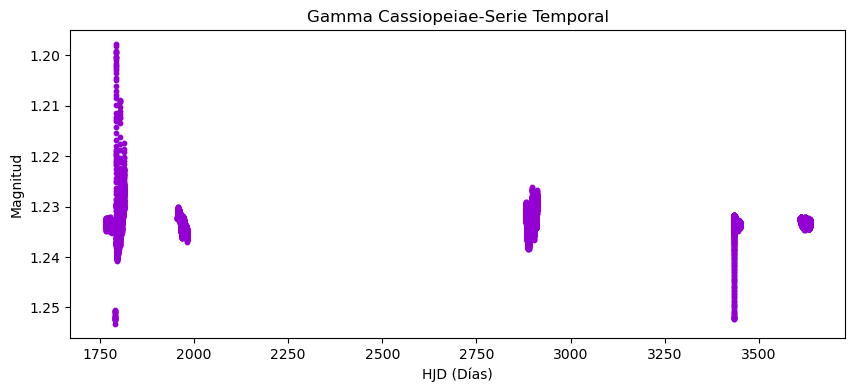

In [ ]:
#Estrella #4 - Gamma Cassiopeiae
gamma_cas = pd.read_csv("gamma cas_s_all.csv")
hjd = gamma_cas['time'].values
magnitude = gamma_cas['mag'].values
error = gamma_cas['mag_err'].values
plt.figure(figsize=(10, 4))
plt.scatter(hjd, magnitude, s=10, color='darkviolet')
plt.gca().invert_yaxis()
plt.title('Gamma Cassiopeiae-Serie Temporal')
plt.xlabel('HJD (Días)')
plt.ylabel('Magnitud')
plt.savefig('4-Serie_Temporal.png', dpi=300)
plt.show()

C:\Users\simon\AppData\Local\Temp\ipykernel_3908\3693598921.py:13: RankWarning: Polyfit may be poorly conditioned
  coeficientes = np.polyfit(hjd_cas, magnitude_cas, grado_polinomio)


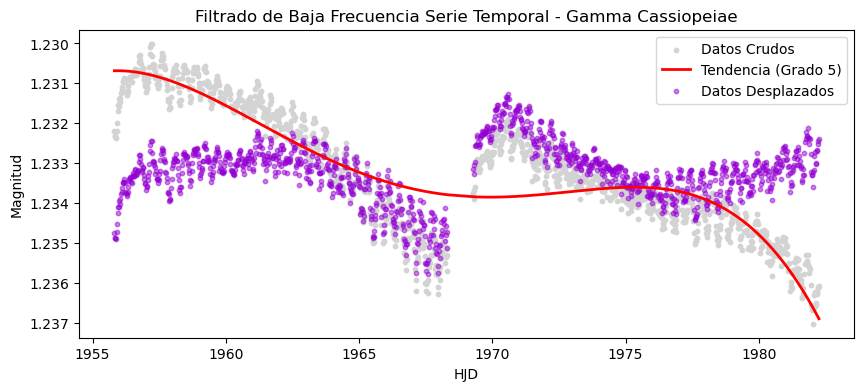


--- Iniciando Pre-blanqueo para Gamma Cassiopeiae ---


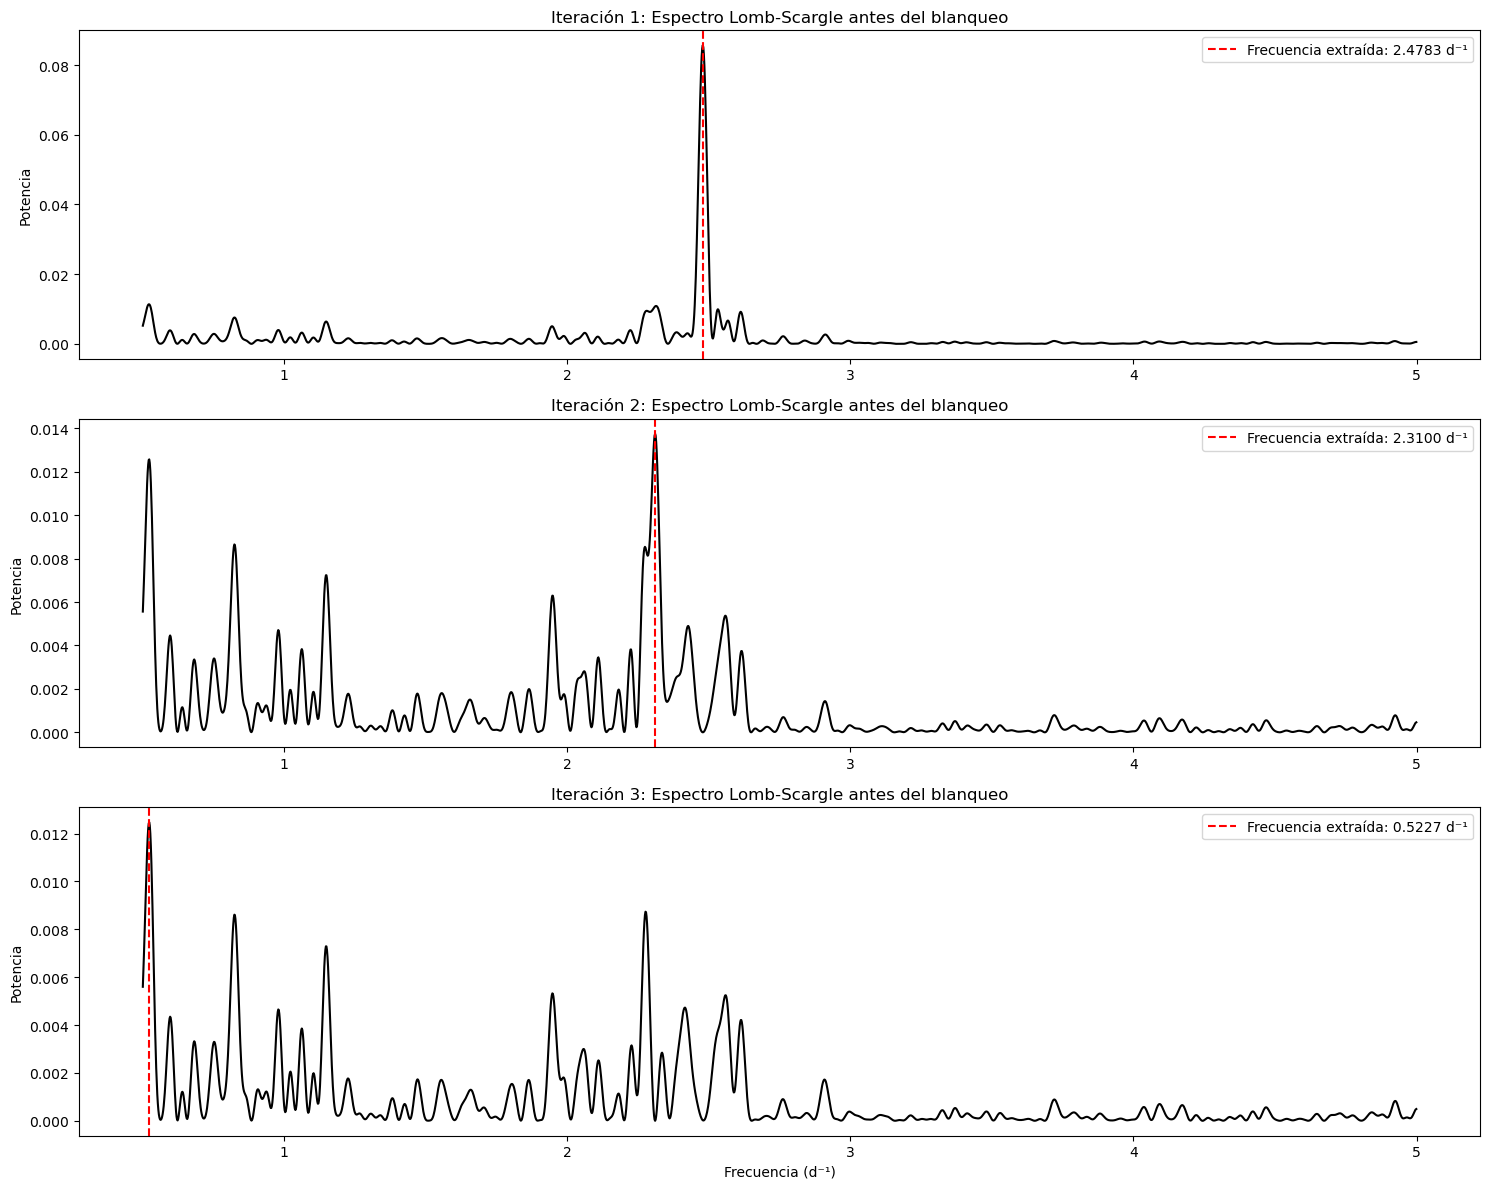


Frecuencias de modos no radiales detectadas:
Modo 1: f = 2.4785 d⁻¹ (Periodo = 0.4035 días)
Modo 2: f = 2.3099 d⁻¹ (Periodo = 0.4329 días)
Modo 3: f = 0.5223 d⁻¹ (Periodo = 1.9147 días)


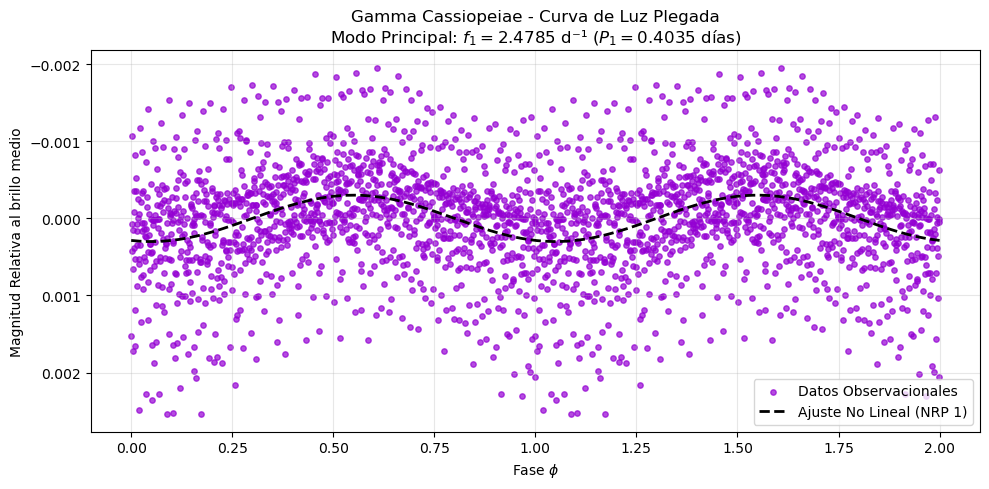

In [ ]:
# =========================================================
# 0. AISLAMIENTO DE LA FASE 
# =========================================================
mascara = (hjd > 1950) & (hjd < 2000)
hjd_cas = hjd[mascara]
magnitude_cas = magnitude[mascara]

# =========================================================
# 1. DETRENDING: Modelado analítico de la variación del disco
# =========================================================
grado_polinomio = 5  
coeficientes = np.polyfit(hjd_cas, magnitude_cas, grado_polinomio)
tendencia_disco = np.polyval(coeficientes, hjd_cas)


magnitud_detrended = magnitude_cas - tendencia_disco


plt.figure(figsize=(10, 4))
plt.scatter(hjd_cas, magnitude_cas, s=10, color='lightgray', label='Datos Crudos')
plt.plot(hjd_cas, tendencia_disco, color='red', linewidth=2, label=f'Tendencia (Grado {grado_polinomio})')
plt.scatter(hjd_cas, magnitud_detrended + np.mean(magnitude_cas), s=10, color='darkviolet', alpha=0.5, label='Datos Desplazados')
plt.gca().invert_yaxis()
plt.title('Filtrado de Baja Frecuencia Serie Temporal - Gamma Cassiopeiae')
plt.xlabel('HJD')
plt.ylabel('Magnitud')
plt.legend()
plt.savefig('4-Detrending.png', dpi=300)
plt.show()

# =========================================================
# 2. EJECUCIÓN DEL PRE-BLANQUEO ESTABILIZADO
# =========================================================
print("\n--- Iniciando Pre-blanqueo para Gamma Cassiopeiae ---")

frecuencias_nrp, ruido_final = pre_blanqueo_iterativo(hjd_cas, magnitud_detrended, j=4, max_iter=3)

print("\nFrecuencias de modos no radiales detectadas:")
for idx, freq in enumerate(frecuencias_nrp):
    print(f"Modo {idx+1}: f = {freq:.4f} d⁻¹ (Periodo = {1/freq:.4f} días)")

# =========================================================
# 3. CURVA DE LUZ PLEGADA (PHASE-FOLDING) DEL MODO PRINCIPAL
# =========================================================

f = frecuencias_nrp[0] 
periodo = 1 / f
fase = phase_fold(hjd_cas, periodo) 

plt.figure(figsize=(10, 5))


plt.scatter(fase, magnitud_detrended, s=15, color='darkviolet', alpha=0.7, label='Datos Observacionales')
plt.scatter(fase + 1, magnitud_detrended, s=15, color='darkviolet', alpha=0.7)


def modelo_fase(fase, A, fase_offset, C):
    return A * np.sin(2 * np.pi * fase + fase_offset) + C

p0 = [0.01, 0.0, 0.0]
popt, _ = curve_fit(modelo_fase, fase, magnitud_detrended, p0=p0)
A_ajuste, fase_offset_ajuste, C_ajuste = popt

fase_sintetica = np.linspace(0, 2, 200)
modelo_armonico_ajustado = modelo_fase(fase_sintetica, A_ajuste, fase_offset_ajuste, C_ajuste)

plt.plot(fase_sintetica, modelo_armonico_ajustado, color='black', linewidth=2, linestyle='--', label='Ajuste No Lineal (NRP 1)')

plt.gca().invert_yaxis() 

plt.title(f'Gamma Cassiopeiae - Curva de Luz Plegada\nModo Principal: $f_1 = {f:.4f}$ d⁻¹ ($P_1 = {periodo:.4f}$ días)')
plt.xlabel('Fase $\phi$')
plt.ylabel('Magnitud Relativa al brillo medio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('4-Curva_Luz_Plegada.png', dpi=300)
plt.show()